#### HITL (Human in the loop) in Agentic Ai 2nd E.g

In [29]:
from langgraph.graph import StateGraph, END,START 
from langgraph.graph.message import add_messages 
from typing import TypedDict,Annotated, Literal,Optional
from langgraph.checkpoint.memory import MemorySaver 
from langgraph.types import interrupt, Command
from langchain_openai import ChatOpenAI 
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage, AnyMessage
from dotenv import load_dotenv

In [ ]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm.invoke("say radhey radhey").content

'Radhey Radhey! How can I assist you today?'

In [13]:
class GraphState(TypedDict):
    # message:Annotated[list[BaseMessage],add_messages]  # add reducer 
    question:str 
    answer:str 
    aprove:str 
    default_answer:str 
    
    

In [61]:
def ChatNode(state:GraphState):
    human_acknowledg = interrupt(
        {
            "message":state["question"],
            "ai_message":"need aproval"
        }
    )

    if "aprove" in human_acknowledg:
        if human_acknowledg['aprove'] == "yes":
            response = llm.invoke(f"you are a conversation assistant, write answer of user query : {state['question']} in 50 words.").content
            return {"answer":response}
        else:
            return {"default_answer":"User is not allowed to write answer"}
    


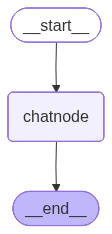

In [70]:
builder = StateGraph(GraphState)
builder.add_node("chatnode",ChatNode)

builder.add_edge(START,"chatnode")
builder.add_edge("chatnode",END)
checkpointer = MemorySaver()
workflow = builder.compile(checkpointer=checkpointer ) 
workflow


In [71]:
initial_state = {"question":"say, Radhey Radhey"}
config = {"configurable":{"thread_id":"user_123"}} 
response = workflow.invoke(initial_state,config=config)

In [64]:
response 

{'question': 'say, Radhey Radhey',
 '__interrupt__': [Interrupt(value={'message': 'say, Radhey Radhey', 'ai_message': 'need aproval'}, id='8439c3e137d55f2a331041b0255536cc')]}

In [65]:
response['__interrupt__'][0].value

{'message': 'say, Radhey Radhey', 'ai_message': 'need aproval'}

In [66]:
response_with_aproval  = workflow.invoke(Command(resume={"question":"say, Radhey Radhey","aprove": "yes"}), config=config)


In [67]:
response_with_aproval

{'question': 'say, Radhey Radhey',
 'answer': 'Radhey Radhey! This greeting is a beautiful expression of devotion and respect in the context of Hindu culture, particularly among followers of Lord Krishna. It signifies acknowledgment and reverence, often used in prayers and conversations. Embracing this phrase fosters a sense of community, love, and connection to divine grace.'}

In [72]:
response_with_aproval  = workflow.invoke(Command(resume={"question":"say, Radhey Radhey"}), config=config)


In [73]:
response_with_aproval

{'question': 'say, Radhey Radhey'}